# Buổi 1 — Khám phá và kiểm tra tính hợp lệ của thử nghiệm

Bộ dữ liệu: Cookie Cats (`data/raw/cookie_cats.csv.zip`)

## 1. Nạp dữ liệu, xem shape, dtypes, describe()

In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/cookie_cats.csv')

df.shape

(90189, 5)

In [13]:
df.dtypes 

userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object

In [14]:
df.describe()  

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


In [15]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 2. Đếm số người mỗi nhóm — hai nhóm có cân nhau không?

In [16]:
df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

In [18]:
from scipy.stats import chisquare

quan_sat = df['version'].value_counts()
chisquare(quan_sat)   # mặc định so với kỳ vọng chia đều


Power_divergenceResult(statistic=np.float64(6.9024049496058275), pvalue=np.float64(0.008607987810836243))

## 3. Kiểm tra userid có trùng không

In [20]:
df['userid'].nunique()  == len(df)

True

## 4. Phân bố sum_gamerounds — histogram, so trung bình với trung vị

In [21]:
df['sum_gamerounds'].mean()

np.float64(51.8724567297564)

In [22]:
df['sum_gamerounds'].median()

np.float64(16.0)

<Axes: >

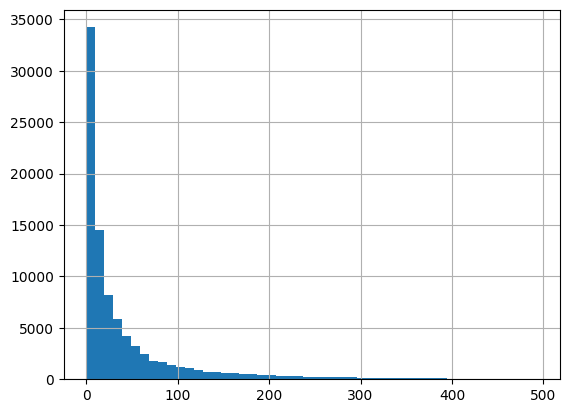

In [24]:
df['sum_gamerounds'].hist(bins=50, range=(0, df["sum_gamerounds"].quantile(0.99)))


## 5. Tìm giá trị bất thường ở đuôi phải

In [26]:
df['sum_gamerounds'].nlargest(10)

57702    49854
7912      2961
29417     2640
43671     2438
48188     2294
46344     2251
87007     2156
36933     2124
88328     2063
6536      2015
Name: sum_gamerounds, dtype: int64

In [27]:
df.nlargest(10, 'sum_gamerounds')

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True
46344,5133952,gate_30,2251,True,True
87007,9640085,gate_30,2156,True,True
36933,4090246,gate_40,2124,True,True
88328,9791599,gate_40,2063,True,True
6536,725080,gate_40,2015,True,True


In [42]:
q1 = df["sum_gamerounds"].quantile(0.25)
q3 = df["sum_gamerounds"].quantile(0.75)
iqr = q3 - q1
nguong_tren = q3 + 1.5 * iqr

df[df["sum_gamerounds"] > nguong_tren].shape[0]


10177

## Ghi chú quyết định (đưa sang docs/data_quality.md)

- Người chơi 0 vòng — giữ hay loại, vì sao? 
**Quyết định:** giữ người chơi 0 vòng khi tính retention.
**Lý do:** vì loại đi tức là bỏ luôn 87+29-5=111 người có tín hiệu retention thật, trong khi không có bằng chứng cụ thể nào nói đó là lỗi, chỉ là nghi ngờ.
**Giới hạn:** không có cách nào từ dữ liệu hiện có để biết sum_gamerounds=0 là do thật sự chưa mở lại app, hay do sự kiện chơi và sự kiện mở app được ghi nhận từ hai nguồn khác nhau.

- Giá trị cực đại — bot hay người chơi thật, ảnh hưởng thế nào tới trung bình?
Giá trị cực đại khả năng cao do bot vì dựa theo dữ liệu sum_gamerounds của case này gấp 16,84 lần so với case có sum_gamerounds lớn thứ 2 (gần tương đương case lớn thứ 3 và các dữ liệu trong top còn lại). Việc này kéo trung bình lên khoảng 1% (Trung bình toàn bộ (90.189 người): 51.87, Trung bình nếu bỏ riêng 1 ca 49.854 vòng: 51.32 => Chênh lệch: 0.55 (≈ 1%)).
**Giới hạn:** dữ liệu hiện có (userid, version, sum_gamerounds, retention_1/7) không có thông tin nào khác (như tần suất phiên chơi, thiết bị, IP...) để xác nhận chắc chắn đây là bot; đây chỉ là suy luận dựa trên độ lớn bất thường của một con số, chưa phải bằng chứng trực tiếp.

In [29]:
df[df["sum_gamerounds"] == 0].shape[0]

3994

In [37]:
len(df[(df['sum_gamerounds'] == 0) & (df['retention_1'] == True)])

87

In [36]:
len(df[(df['sum_gamerounds'] == 0) & (df['retention_7'] == True)])

29

In [39]:
len(df[(df['sum_gamerounds'] == 0) & (df['retention_1'] == True) & (df['retention_7'] == True)])

5

In [40]:
df['sum_gamerounds'].mean()


np.float64(51.8724567297564)

In [45]:
df[df["sum_gamerounds"] < nguong_tren]["sum_gamerounds"].mean()


np.float64(23.860222992504347)

In [47]:
idx_max = df['sum_gamerounds'].idxmax()
df.drop(idx_max)["sum_gamerounds"].mean()


np.float64(51.32025324876924)